# Qiskit 101 — Lab 01

## Exploring a Single Qubit

### Overview

In Lab 00, we set up Qiskit in Google Colab and created our first two-qubit Bell-state circuit.

In this laboratory, we step back and study the fundamental computational unit of a quantum computer: the **qubit**.

Unlike a classical bit, which can have the value `0` or `1`, a qubit can exist in a quantum state described by

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

where \(\alpha\) and \(\beta\) are complex probability amplitudes satisfying

$$
|\alpha|^2 + |\beta|^2 = 1.
$$

When the qubit is measured in the computational basis, the probability of obtaining `0` is

$$
P(0)=|\alpha|^2
$$

and the probability of obtaining `1` is

$$
P(1)=|\beta|^2.
$$

In this laboratory, we will use Qiskit to prepare, manipulate, visualize, and measure different single-qubit states.

---

## Learning Objectives

After completing this laboratory, you should be able to:

1. Create a single-qubit quantum circuit using Qiskit.
2. Prepare the computational basis states \(|0\rangle\) and \(|1\rangle\).
3. Create superposition states using the Hadamard gate.
4. Apply the Pauli X, Y, and Z gates and explain their effects.
5. Distinguish between changes in measurement probabilities and changes in quantum phase.
6. Apply single-qubit rotation gates \(R_x\), \(R_y\), and \(R_z\).
7. Obtain and interpret the statevector of a qubit.
8. Visualize single-qubit states using the Bloch sphere.
9. Predict measurement outcomes before executing a circuit.
10. Prepare a specified single-qubit state using Qiskit.

---

## Learning Approach

Throughout this laboratory, follow the cycle:

> **Predict → Build → Visualize → Execute → Observe → Explain**

Do not immediately execute each circuit.

First ask:

**What quantum state should this circuit produce, and what should I observe when I measure it?**

Then use Qiskit to test your prediction.



In [ ]:
%pip install -q "qiskit[visualization]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.9 MB/s eta 0:00:00


## 1. Creating a Single Qubit

A Qiskit quantum circuit is created using the `QuantumCircuit` class.

The following instruction creates a circuit containing **one qubit**:

`QuantumCircuit(1)`

Qiskit initializes every qubit in the computational basis state

$$
|0\rangle =
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

Therefore, we do not need to perform any operation to prepare \(|0\rangle\).

The circuit currently contains a qubit but **no quantum gates and no measurement operations**.

### Predict

If we measured this qubit repeatedly without applying any gate, what result would you expect?

Think about your answer before continuing.


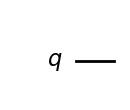

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)

qc.draw("mpl")

## 2. Preparing the State |1〉

A newly created Qiskit qubit begins in the state \(|0\rangle\).

To change it to \(|1\rangle\), we use the **Pauli-X gate**.

The X gate performs the transformation

$$
X|0\rangle = |1\rangle
$$

and

$$
X|1\rangle = |0\rangle.
$$

For this reason, the X gate is sometimes compared with the classical NOT operation.

### Predict

Starting with \(|0\rangle\), what measurement result should we obtain after applying an X gate?

Will the result be deterministic or probabilistic?


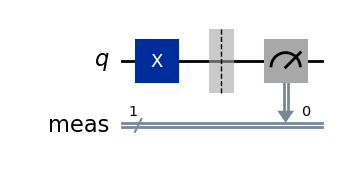

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)
qc.measure_all()

qc.draw("mpl")

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc], shots=1024)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)

{'1': 1024}


## 3. Creating Superposition with the Hadamard Gate

One of the most important single-qubit operations is the **Hadamard gate**, denoted by \(H\).

When H is applied to \(|0\rangle\), it creates the state

$$
|+\rangle =
\frac{|0\rangle+|1\rangle}{\sqrt{2}}.
$$

The probability amplitudes of \(|0\rangle\) and \(|1\rangle\) therefore have equal magnitude.

When measured in the computational basis,

$$
P(0)=\frac{1}{2},
\qquad
P(1)=\frac{1}{2}.
$$

This does **not** mean that the qubit is secretly either 0 or 1 before measurement. The qubit is in a quantum superposition described by a single quantum state.

### Predict

If we execute the circuit 1,000 times:

1. Will every measurement give the same result?
2. What approximate percentage of measurements should produce `0`?
3. What approximate percentage should produce `1`?
4. Will the counts necessarily be exactly 500 and 500?

Write down your prediction before executing the circuit.


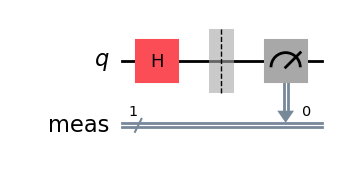

In [ ]:
qc = QuantumCircuit(1)

qc.h(0)
qc.measure_all()

qc.draw("mpl")

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc], shots=1024)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)

{'0': 534, '1': 490}


## 4. 0 Measurement Recap

When a quantum circuit is measured, the quantum state is converted into a classical outcome.

A **shot** is one execution and measurement of the circuit.

Repeating the circuit for many shots produces **counts**, such as

`{'0': 512, '1': 512}`.

These counts provide experimental estimates of the underlying probabilities.

For example, if

$$
|\psi\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2},
$$

then theoretically

$$
P(0)=P(1)=0.5.
$$

With 1,024 shots, the observed counts may not be exactly 512 and 512 because of statistical sampling variation.

Therefore:

* **Amplitude** describes the quantum state.
* **Probability** is obtained from the squared magnitude of an amplitude.
* **Shot** is one circuit execution and measurement.
* **Count** records how many times each classical outcome was observed.
* **Relative frequency** estimates the corresponding probability.

Increasing the number of shots generally makes observed frequencies approach the theoretical probabilities more closely.


## 5. Exploring the Pauli X, Y, and Z Gates

The **Pauli gates** are three fundamental single-qubit quantum operations:

$$
X,\qquad Y,\qquad Z
$$

They are represented by the matrices

$$
X=
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix},
\qquad
Y=
\begin{bmatrix}
0 & -i\\
i & 0
\end{bmatrix},
\qquad
Z=
\begin{bmatrix}
1 & 0\\
0 & -1
\end{bmatrix}.
$$

Although all three are single-qubit gates, they affect a qubit in different ways.

* **X gate:** flips \(|0\rangle\) and \(|1\rangle\).
* **Y gate:** flips the computational-basis state and introduces a phase.
* **Z gate:** changes the relative phase between \(|0\rangle\) and \(|1\rangle\) but does not directly change computational-basis measurement probabilities.

In this section, we will investigate each gate experimentally.

For every experiment, follow:

> **Predict → Execute → Observe → Explain**


### 5.1 Pauli-X Gate — Quantum Bit Flip

The Pauli-X gate transforms the computational-basis states as

$$
X|0\rangle=|1\rangle
$$

and

$$
X|1\rangle=|0\rangle.
$$

It therefore behaves similarly to the classical NOT operation when acting on the computational basis.

We will begin with the default Qiskit state \(|0\rangle\), apply the X gate, and then measure the qubit.

### Predict

Before executing the code:

1. What is the initial state?
2. What state will X produce?
3. What measurement result should appear?
4. Is the result deterministic or probabilistic?



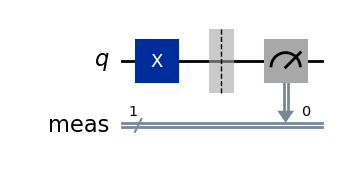

In [ ]:
from qiskit import QuantumCircuit

qc_x = QuantumCircuit(1)

qc_x.x(0)
qc_x.measure_all()

qc_x.draw("mpl")

#### Execute the X-Gate Circuit

We will now execute the circuit using `StatevectorSampler`.

Because the X gate transforms \(|0\rangle\) into \(|1\rangle\), an ideal simulator should return `1` for every shot.


In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc_x], shots=1024)
result = job.result()

counts_x = result[0].data.meas.get_counts()

print(counts_x)

{'1': 1024}


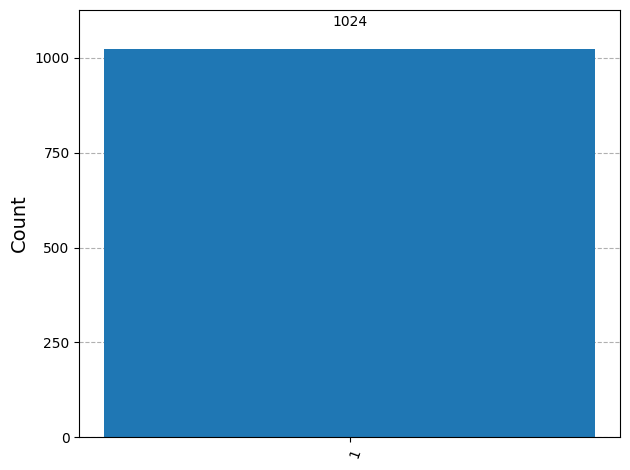

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_x)

### 5.2 Pauli-Y Gate — Bit Flip with Phase

The Pauli-Y gate acts on the computational-basis states as

$$
Y|0\rangle=i|1\rangle
$$

and

$$
Y|1\rangle=-i|0\rangle.
$$

Notice that Y changes \(|0\rangle\) to \(|1\rangle\), similar to the X gate, but it also introduces a complex phase factor.

Starting from \(|0\rangle\),

$$
|0\rangle
\xrightarrow{Y}
i|1\rangle.
$$

If we measure immediately in the computational basis, the phase factor \(i\) does not affect the measurement probability.

Therefore,

$$
P(1)=1.
$$

### Predict

What measurement outcome do you expect after applying Y to \(|0\rangle\)?

Will the histogram look different from the X-gate experiment?

If the histograms are identical, does that mean X and Y perform exactly the same quantum operation?


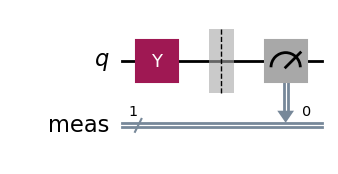

In [ ]:
qc_y = QuantumCircuit(1)

qc_y.y(0)
qc_y.measure_all()

qc_y.draw("mpl")

#### Execute the Y-Gate Circuit

The Y gate changes the initial state \(|0\rangle\) to \(i|1\rangle\).

The complex factor \(i\) changes the phase of the quantum state but not the probability of measuring `1`.

We therefore expect all measurements to produce `1`.


In [ ]:
job = sampler.run([qc_y], shots=1024)
result = job.result()

counts_y = result[0].data.meas.get_counts()

print(counts_y)

{'1': 1024}


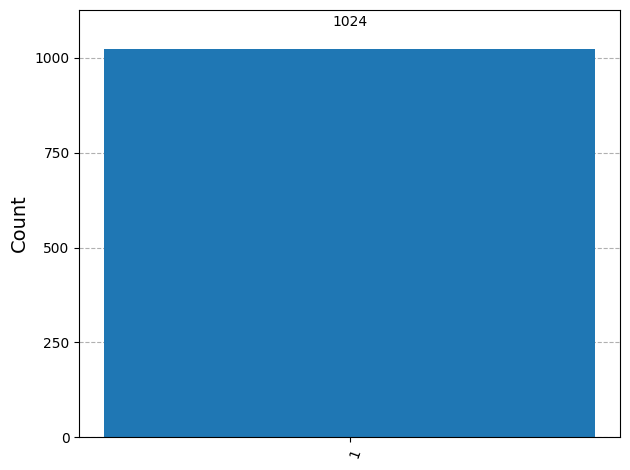

In [ ]:
plot_histogram(counts_y)

#### Observation

The measurement histogram for Y may look identical to the histogram for X:

`1` occurs with probability 1.

However,

$$
X|0\rangle=|1\rangle
$$

whereas

$$
Y|0\rangle=i|1\rangle.
$$

The difference is in the **quantum phase**.

This illustrates an important principle:

> Two quantum states can produce identical measurement probabilities in one measurement basis while still being different quantum states.

We will later use statevectors and the Bloch sphere to observe this difference.


### 5.3 Pauli-Z Gate — Phase Flip

The Pauli-Z gate behaves differently from X and Y.

It acts as

$$
Z|0\rangle=|0\rangle
$$

and

$$
Z|1\rangle=-|1\rangle.
$$

Therefore, Z does **not exchange** the computational-basis states.

Instead, it changes the phase associated with the \(|1\rangle\) component.

If we apply Z directly to the initial state \(|0\rangle\),

$$
Z|0\rangle=|0\rangle.
$$

### Predict

If we apply Z to \(|0\rangle\) and immediately measure:

1. Will the qubit change from 0 to 1?
2. What measurement result do you expect?
3. Will the result look different from a circuit containing no gate at all?


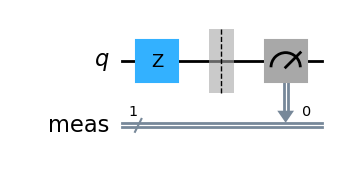

In [ ]:
qc_z = QuantumCircuit(1)

qc_z.z(0)
qc_z.measure_all()

qc_z.draw("mpl")

In [ ]:
job = sampler.run([qc_z], shots=1024)
result = job.result()

counts_z = result[0].data.meas.get_counts()

print(counts_z)

{'0': 1024}


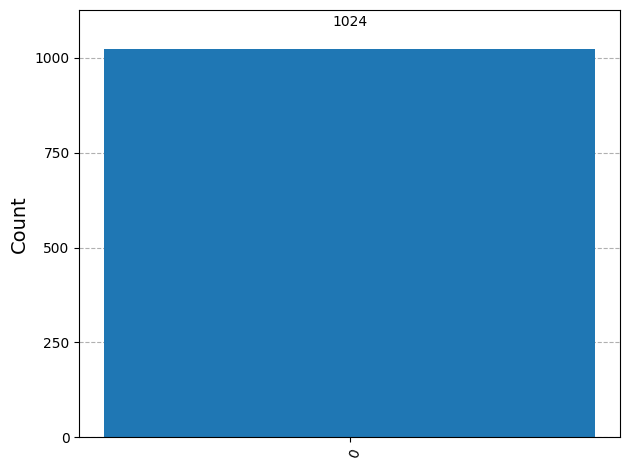

In [ ]:
plot_histogram(counts_z)

## 5.4 Does the Z Gate Really Do Nothing?

In the previous experiment, applying Z to \(|0\rangle\) produced exactly the same measurement result as applying no gate.

This may suggest that the Z gate has no effect.

However, Z acts on **phase**, and phase becomes meaningful when the qubit is in a superposition.

Let us first create

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

using the Hadamard gate.

Now apply Z:

$$
Z|+\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt2}
=
|-\rangle.
$$

Thus,

$$
|+\rangle \xrightarrow{Z} |-\rangle.
$$

The probabilities of measuring 0 or 1 immediately are still 50%–50%, but the quantum state has changed because its **relative phase** has changed.

### Predict

If we measure immediately after H → Z, what distribution should we observe?

Will computational-basis measurement alone reveal that the state changed from \(|+\rangle\) to \(|-\rangle\)?


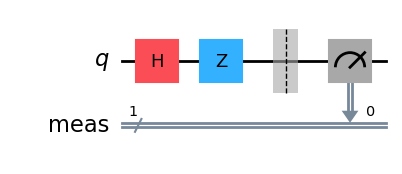

In [ ]:
qc_z_phase = QuantumCircuit(1)

qc_z_phase.h(0)
qc_z_phase.z(0)
qc_z_phase.measure_all()

qc_z_phase.draw("mpl")

In [ ]:
job = sampler.run([qc_z_phase], shots=1024)
result = job.result()

counts_z_phase = result[0].data.meas.get_counts()

print(counts_z_phase)

{'1': 503, '0': 521}


## 5.5 Revealing the Effect of Phase

Computational-basis measurement cannot directly distinguish between

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

and

$$
|-\rangle=
\frac{|0\rangle-|1\rangle}{\sqrt2}.
$$

Both produce approximately 50% `0` and 50% `1`.

To reveal the phase difference, apply another Hadamard gate before measurement.

Recall:

$$
H|+\rangle=|0\rangle
$$

and

$$
H|-\rangle=|1\rangle.
$$

Therefore,

$$
|0\rangle
\xrightarrow{H}
|+\rangle
\xrightarrow{Z}
|-\rangle
\xrightarrow{H}
|1\rangle.
$$

### Predict

What measurement outcome should the circuit

**H → Z → H**

produce?

Compare this with

**H → H**.

This experiment demonstrates how phase information can later be converted into observable measurement information through **interference**.


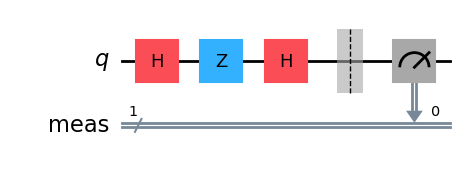

In [ ]:
qc_hzh = QuantumCircuit(1)

qc_hzh.h(0)
qc_hzh.z(0)
qc_hzh.h(0)

qc_hzh.measure_all()

qc_hzh.draw("mpl")

In [ ]:
job = sampler.run([qc_hzh], shots=1024)
result = job.result()

counts_hzh = result[0].data.meas.get_counts()

print(counts_hzh)

{'1': 1024}


## 5.6 What Have We Learned About the Pauli Gates?

The three Pauli gates affect a single qubit in different ways.

| Gate | Main Effect | On \(|0\rangle\) | On \(|1\rangle\) |
|---|---|---|---|
| X | Bit flip | \(|1\rangle\) | \(|0\rangle\) |
| Y | Bit flip + phase | \(i|1\rangle\) | \(-i|0\rangle\) |
| Z | Phase flip | \(|0\rangle\) | \(-|1\rangle\) |

### Important observations

**X changes computational-basis populations.**

It directly changes the measurement outcome from 0 to 1 or from 1 to 0.

**Y changes both the basis state and its phase.**

Its immediate computational-basis measurement may look identical to X, but the underlying quantum state is different.

**Z changes phase rather than population.**

Its effect may be invisible in a direct computational-basis measurement.

However, phase differences can become observable when followed by operations such as the Hadamard gate.

### Key Insight

> **Quantum gates can modify information that is not immediately visible in a measurement histogram.**

This is why understanding the **quantum state**, and not only its measurement outcomes, is essential.

In the next section, we will use the **statevector and Bloch sphere** to visualize these differences more directly.


## 6. Measurement Probabilities vs Quantum Phase

A quantum state contains more information than the probabilities that we observe when we measure it.

For a general single-qubit state,

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
$$

measurement in the computational basis gives

$$
P(0)=|\alpha|^2,
\qquad
P(1)=|\beta|^2.
$$

Notice that measurement probabilities depend on the **magnitudes** of the amplitudes.

However, the amplitudes \(\alpha\) and \(\beta\) can also contain **phase information**.

For example, consider the two states

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

and

$$
|-\rangle=
\frac{|0\rangle-|1\rangle}{\sqrt2}.
$$

If both states are measured directly in the computational basis,

$$
P(0)=P(1)=\frac12.
$$

Therefore, their measurement histograms look the same.

But the two quantum states are **not the same**.

The difference is the relative phase between their \(|0\rangle\) and \(|1\rangle\) components.

In this section, we will experimentally distinguish between:

1. a change in **measurement probability**, and
2. a change in **quantum phase**.


### 6.1 A Change in Measurement Probability

Start with a qubit in its default state

$$
|0\rangle.
$$

Its computational-basis measurement probabilities are

$$
P(0)=1,\qquad P(1)=0.
$$

Applying the X gate transforms it into

$$
|1\rangle.
$$

The probabilities therefore become

$$
P(0)=0,\qquad P(1)=1.
$$

This is a direct change in the **measurement probability distribution**.

### Predict

Before running the circuits:

* What should the circuit without X produce?
* What should the circuit with X produce?
* Should the difference be directly visible in their measurement histograms?


In [ ]:
qc_probability_0 = QuantumCircuit(1)

qc_probability_0.measure_all()

job = sampler.run([qc_probability_0], shots=1024)
result = job.result()

counts_p0 = result[0].data.meas.get_counts()

print(counts_p0)

{'0': 1024}


In [ ]:
qc_probability_1 = QuantumCircuit(1)

qc_probability_1.x(0)
qc_probability_1.measure_all()

job = sampler.run([qc_probability_1], shots=1024)
result = job.result()

counts_p1 = result[0].data.meas.get_counts()

print(counts_p1)

{'1': 1024}


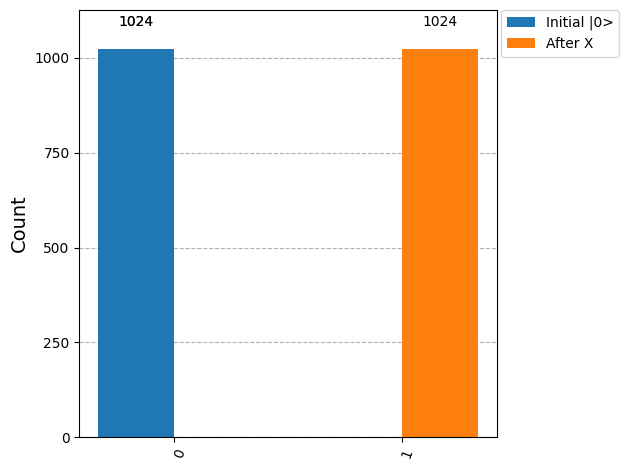

In [ ]:
plot_histogram(
    [counts_p0, counts_p1],
    legend=["Initial |0>", "After X"]
)

### Observation

The X gate changes the measurement distribution directly:

$$
|0\rangle \xrightarrow{X}|1\rangle.
$$

Before X:

$$
P(0)=1.
$$

After X:

$$
P(1)=1.
$$

Therefore, a change in the quantum state has produced an immediately observable change in measurement probabilities.

Next, we will investigate a different type of state change that is **not directly visible** in the same measurement basis.


## 6.2 Changing Quantum Phase

Let us now prepare the state

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

by applying the Hadamard gate to \(|0\rangle\).

If we measure \(|+\rangle\) in the computational basis,

$$
P(0)=\frac12,
\qquad
P(1)=\frac12.
$$

Now apply the Z gate.

The Z gate performs

$$
Z|0\rangle=|0\rangle
$$

and

$$
Z|1\rangle=-|1\rangle.
$$

Therefore,

$$
Z|+\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt2}
=
|-\rangle.
$$

The quantum state has changed from \(|+\rangle\) to \(|-\rangle\).

However,

$$
P(0)=P(1)=\frac12
$$

for both states when measured in the computational basis.

### Predict

We will compare:

**Circuit A**

$$
|0\rangle \rightarrow H \rightarrow \text{Measure}
$$

with

**Circuit B**

$$
|0\rangle \rightarrow H \rightarrow Z \rightarrow \text{Measure}.
$$

Will their measurement histograms look different?

Does an identical histogram necessarily mean that the underlying quantum states are identical?


In [ ]:
qc_plus = QuantumCircuit(1)

qc_plus.h(0)
qc_plus.measure_all()

job = sampler.run([qc_plus], shots=10000)
result = job.result()

counts_plus = result[0].data.meas.get_counts()

print(counts_plus)

{'1': 4978, '0': 5022}


In [ ]:
qc_minus = QuantumCircuit(1)

qc_minus.h(0)
qc_minus.z(0)
qc_minus.measure_all()

job = sampler.run([qc_minus], shots=10000)
result = job.result()

counts_minus = result[0].data.meas.get_counts()

print(counts_minus)

{'1': 5134, '0': 4866}


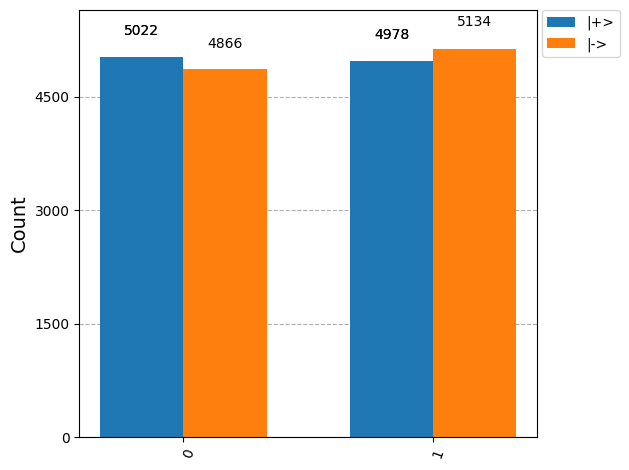

In [ ]:
plot_histogram(
    [counts_plus, counts_minus],
    legend=["|+>", "|->"]
)

### Important Observation

The two histograms are approximately identical.

For \(|+\rangle\),

$$
P(0)=P(1)=\frac12.
$$

For \(|-\rangle\),

$$
P(0)=P(1)=\frac12.
$$

Yet,

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

and

$$
|-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt2}.
$$

The states differ in the **relative phase** of the \(|1\rangle\) component.

This gives us an important quantum-computing principle:

> **Measurement probabilities in one basis do not completely describe a quantum state.**

A phase change can alter the quantum state without changing the probabilities observed in an immediate computational-basis measurement.

How, then, can we detect the phase difference?

We need another quantum operation that converts the phase information into a difference in measurement probabilities.


## 6.3 Converting Phase into Measurement Probability

Although \(|+\rangle\) and \(|-\rangle\) give identical computational-basis measurement probabilities, we can distinguish them by applying another Hadamard gate before measurement.

The Hadamard gate satisfies

$$
H|+\rangle=|0\rangle
$$

and

$$
H|-\rangle=|1\rangle.
$$

Therefore,

### Circuit A

$$
|0\rangle
\xrightarrow{H}
|+\rangle
\xrightarrow{H}
|0\rangle
$$

while

### Circuit B

$$
|0\rangle
\xrightarrow{H}
|+\rangle
\xrightarrow{Z}
|-\rangle
\xrightarrow{H}
|1\rangle.
$$

The Z gate originally changed only the relative phase.

The second H gate converts that phase difference into a measurable difference in probability.

### Predict

What will be measured for:

* **H → H**
* **H → Z → H**

Write down your prediction before running the circuits.


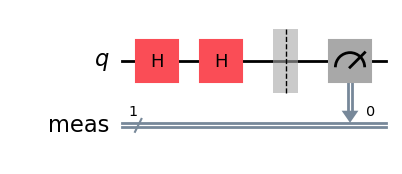

In [ ]:
qc_hh = QuantumCircuit(1)

qc_hh.h(0)
qc_hh.h(0)
qc_hh.measure_all()

qc_hh.draw("mpl")

In [ ]:
job = sampler.run([qc_hh], shots=1024)
result = job.result()

counts_hh = result[0].data.meas.get_counts()

print(counts_hh)

{'0': 1024}


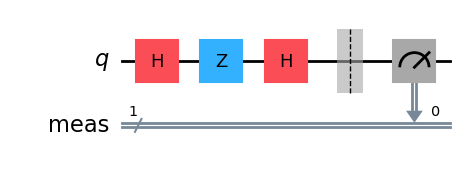

In [ ]:
qc_hzh = QuantumCircuit(1)

qc_hzh.h(0)
qc_hzh.z(0)
qc_hzh.h(0)
qc_hzh.measure_all()

qc_hzh.draw("mpl")

In [ ]:
job = sampler.run([qc_hzh], shots=1024)
result = job.result()

counts_hzh = result[0].data.meas.get_counts()

print(counts_hzh)

{'1': 1024}


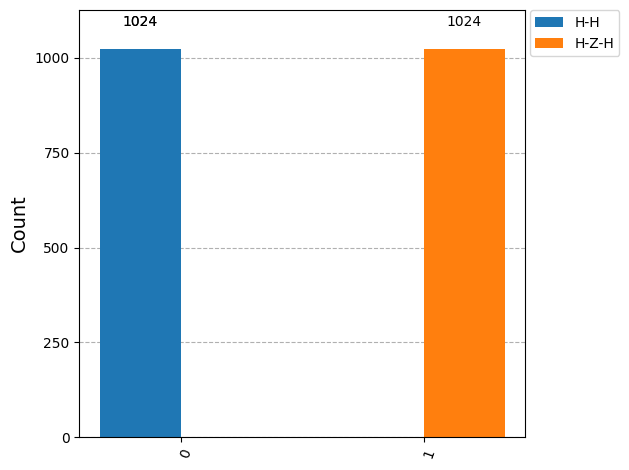

In [ ]:
plot_histogram(
    [counts_hh, counts_hzh],
    legend=["H-H", "H-Z-H"]
)

 ## 6.4 Probability Change vs Phase Change

We can now distinguish two different ways in which a quantum gate can affect a qubit.

| Type of Change        | What Changes?                     | Immediately Visible in Z-Basis Measurement? | Example |           |           |
| --------------------- | --------------------------------- | ------------------------------------------- | ------- | --------- | --------- |
| Probability change    | Magnitudes of amplitudes          | Usually yes                                 | (X      | 0\rangle= | 1\rangle) |
| Relative phase change | Relative phase between amplitudes | Not necessarily                             | (Z      | +\rangle= | -\rangle) |

For the general state

$$
|\psi\rangle
=
\alpha|0\rangle+\beta|1\rangle,
$$

measurement probabilities depend on

$$
|\alpha|^2
\quad\text{and}\quad
|\beta|^2.
$$

But the quantum state also contains information about the **relative phase** between \(\alpha\) and \(\beta\).

### Central Idea

> **Probability determines how frequently measurement outcomes occur, whereas relative phase determines how probability amplitudes can interfere during later quantum operations.**

This explains why phase is extremely important in quantum computing even when it is not directly visible in an immediate measurement.

The sequence

$$
H \rightarrow Z \rightarrow H
$$

provides a simple example:

1. The first H creates superposition.
2. Z changes the relative phase.
3. The second H creates interference.
4. The phase difference becomes a measurable probability difference.

### Remember

> **Same measurement probabilities do not necessarily mean the same quantum state.**


## 7. Single-Qubit Rotation Gates

So far, we have used gates such as X, Y, Z, and H. These gates perform fixed transformations.

Qiskit also provides **parameterized rotation gates** that rotate a qubit state by a chosen angle:

$$
R_x(\theta), \qquad R_y(\theta), \qquad R_z(\theta)
$$

where \(\theta\) is the rotation angle in radians.

These gates can be understood geometrically as rotations of the qubit state around the corresponding axes of the Bloch sphere:

* \(R_x(\theta)\): rotation around the x-axis
* \(R_y(\theta)\): rotation around the y-axis
* \(R_z(\theta)\): rotation around the z-axis

Because the angle can be varied continuously, rotation gates are fundamental in parameterized quantum circuits, variational algorithms, quantum machine learning, and quantum control.

In this section, we will explore how each rotation gate affects a single qubit.

> **Predict → Apply Rotation → Measure → Observe → Explain**


### 7.1 Rotation Around the X-Axis: \(R_x(\theta)\)

The \(R_x\) gate rotates the state of a qubit around the x-axis of the Bloch sphere.

Its matrix is

$$
R_x(\theta)
=
\begin{bmatrix}
\cos(\theta/2) & -i\sin(\theta/2)\\
-i\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}.
$$

Starting from \(|0\rangle\),

$$
R_x(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
-
i\sin(\theta/2)|1\rangle.
$$

Therefore,

$$
P(0)=\cos^2(\theta/2)
$$

and

$$
P(1)=\sin^2(\theta/2).
$$

Let us begin with

$$
\theta=\frac{\pi}{2}.
$$

For this angle,

$$
P(0)=P(1)=\frac12.
$$

### Predict

Before running the circuit:

1. Will the qubit be measured as only `0`, only `1`, or both?
2. What approximate percentage of `0` and `1` do you expect?
3. Would \(R_x(\pi)\) produce a different result?


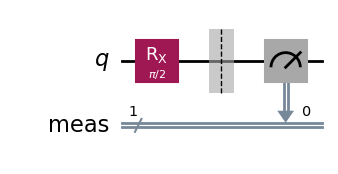

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

qc_rx = QuantumCircuit(1)

qc_rx.rx(pi/2, 0)
qc_rx.measure_all()

qc_rx.draw("mpl")

#### Execute the \(R_x(\pi/2)\) Circuit

The circuit is executed for 1,024 shots.

Since

$$
R_x(\pi/2)|0\rangle
=
\frac{1}{\sqrt2}|0\rangle
-
\frac{i}{\sqrt2}|1\rangle,
$$

we expect approximately equal probabilities for measuring `0` and `1`.


{'1': 516, '0': 508}


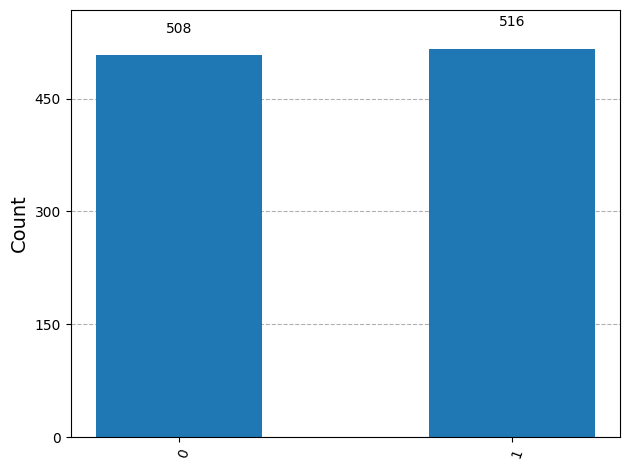

In [ ]:
job = sampler.run([qc_rx], shots=1024)
result = job.result()

counts_rx = result[0].data.meas.get_counts()

print(counts_rx)
plot_histogram(counts_rx)

{'1': 1024}


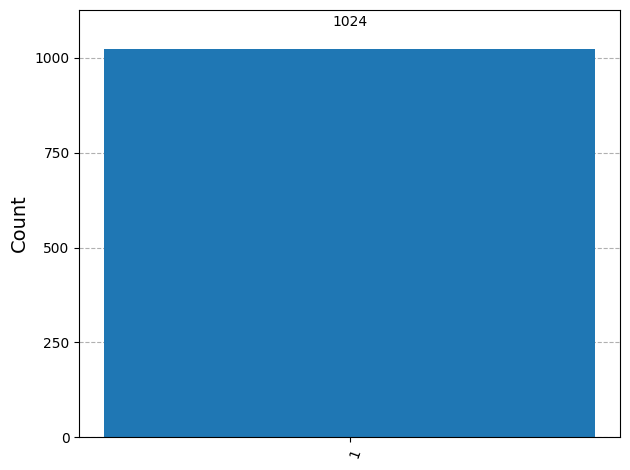

In [ ]:
qc_rx_pi = QuantumCircuit(1)

qc_rx_pi.rx(pi, 0)
qc_rx_pi.measure_all()

job = sampler.run([qc_rx_pi], shots=1024)
result = job.result()

counts_rx_pi = result[0].data.meas.get_counts()

print(counts_rx_pi)
plot_histogram(counts_rx_pi)

### Observation

For

$$
R_x(\pi/2),
$$

the measurement results are approximately 50% `0` and 50% `1`.

For

$$
R_x(\pi),
$$

the state becomes, apart from a phase factor,

$$
|1\rangle.
$$

Therefore, the measurement result becomes `1` with probability 1.

This shows how varying the angle continuously changes the measurement probabilities.


### 7.2 Rotation Around the Y-Axis: \(R_y(\theta)\)

The \(R_y\) gate rotates a qubit around the y-axis of the Bloch sphere.

Its matrix is

$$
R_y(\theta)
=
\begin{bmatrix}
\cos(\theta/2) & -\sin(\theta/2)\\
\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}.
$$

When applied to \(|0\rangle\),

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
+
\sin(\theta/2)|1\rangle.
$$

Therefore,

$$
P(0)=\cos^2(\theta/2),
\qquad
P(1)=\sin^2(\theta/2).
$$

Notice that these measurement probabilities are the same as for \(R_x(\theta)\) when starting from \(|0\rangle\).

However, the quantum states are not identical because the relative phases of their amplitudes are different.

Let us use

$$
\theta=\frac{\pi}{2}.
$$

### Predict

What measurement probabilities do you expect?

Will the histogram look similar to the \(R_x(\pi/2)\) histogram?

If so, does that necessarily mean that \(R_x\) and \(R_y\) created the same quantum state?


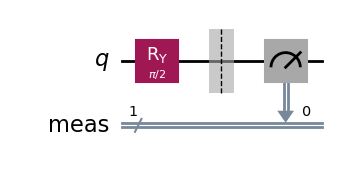

In [ ]:
qc_ry = QuantumCircuit(1)

qc_ry.ry(pi/2, 0)
qc_ry.measure_all()

qc_ry.draw("mpl")

{'1': 516, '0': 508}


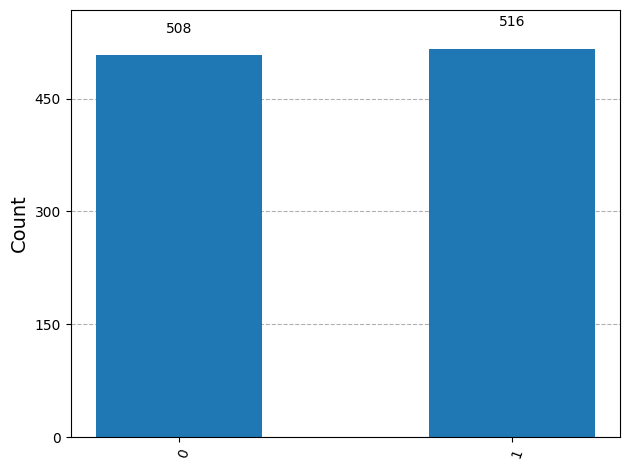

In [ ]:
job = sampler.run([qc_ry], shots=1024)
result = job.result()

counts_ry = result[0].data.meas.get_counts()

print(counts_ry)
plot_histogram(counts_ry)

### Observation

For

$$
R_y(\pi/2)|0\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}
=
|+\rangle.
$$

Therefore, computational-basis measurement gives approximately

$$
50\%\;0
\qquad\text{and}\qquad
50\%\;1.
$$

This measurement histogram may look very similar to that of \(R_x(\pi/2)\).

However,

$$
R_y(\pi/2)|0\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2},
$$

whereas

$$
R_x(\pi/2)|0\rangle
=
\frac{|0\rangle-i|1\rangle}{\sqrt2}.
$$

Their probabilities are the same, but their relative phases are different.

This reinforces an important idea from the previous section:

> **Identical measurement probabilities do not necessarily imply identical quantum states.**


### 7.3 Rotation Around the Z-Axis: \(R_z(\theta)\)

The \(R_z\) gate rotates a qubit around the z-axis of the Bloch sphere.

Its matrix is

$$
R_z(\theta)
=
\begin{bmatrix}
e^{-i\theta/2} & 0\\
0 & e^{i\theta/2}
\end{bmatrix}.
$$

Unlike \(R_x\) and \(R_y\), an \(R_z\) rotation does not directly change the computational-basis populations.

If the qubit is initially in \(|0\rangle\),

$$
R_z(\theta)|0\rangle
=
e^{-i\theta/2}|0\rangle.
$$

The factor \(e^{-i\theta/2}\) is only a global phase for this state.

Therefore, if we apply \(R_z\) directly to \(|0\rangle\) and measure immediately,

$$
P(0)=1.
$$

To observe the physically meaningful effect of \(R_z\), we should first create a superposition.


{'0': 1024}


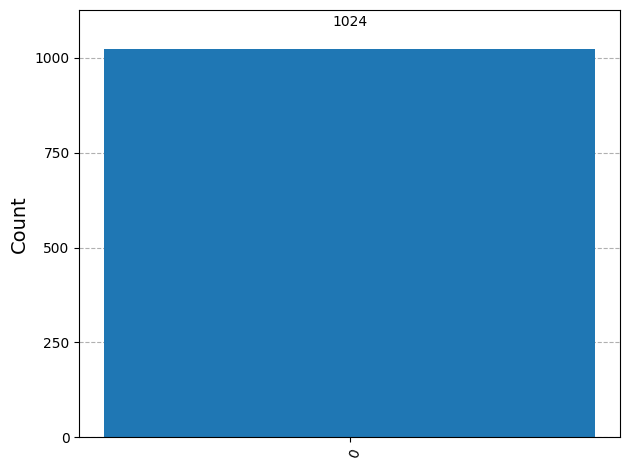

In [ ]:
qc_rz0 = QuantumCircuit(1)

qc_rz0.rz(pi/2, 0)
qc_rz0.measure_all()

job = sampler.run([qc_rz0], shots=1024)
result = job.result()

counts_rz0 = result[0].data.meas.get_counts()

print(counts_rz0)
plot_histogram(counts_rz0)

### Revealing the Effect of \(R_z\)

To observe the effect of \(R_z\), first prepare

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

using a Hadamard gate.

Then apply

$$
R_z(\theta).
$$

The relative phase between the \(|0\rangle\) and \(|1\rangle\) components changes.

For \(\theta=\pi\), the resulting state is equivalent, up to a global phase, to

$$
|-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt2}.
$$

If we measure immediately in the computational basis, we still observe approximately 50% `0` and 50% `1`.

Therefore, we again need interference to reveal the phase difference.

Adding a final Hadamard converts the phase difference into a measurable probability difference.


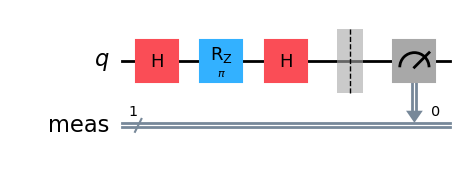

In [ ]:
qc_rz = QuantumCircuit(1)

qc_rz.h(0)
qc_rz.rz(pi, 0)
qc_rz.h(0)

qc_rz.measure_all()

qc_rz.draw("mpl")

{'1': 1024}


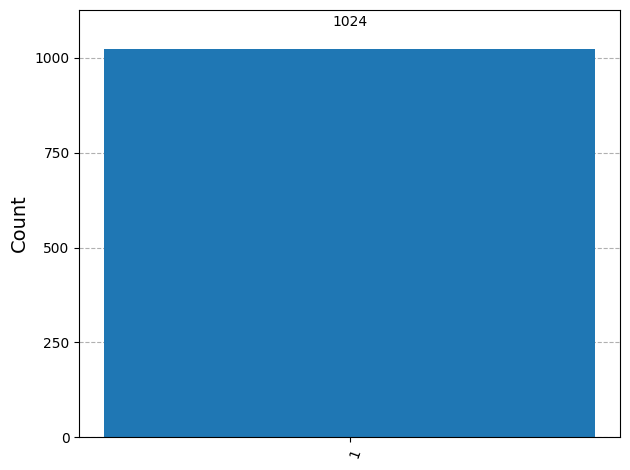

In [ ]:
job = sampler.run([qc_rz], shots=1024)
result = job.result()

counts_rz = result[0].data.meas.get_counts()

print(counts_rz)
plot_histogram(counts_rz)

## 7.4 How Does the Rotation Angle Affect Measurement Probability?

For a qubit initially in \(|0\rangle\), both \(R_x(\theta)\) and \(R_y(\theta)\) produce computational-basis probabilities

$$
P(0)=\cos^2(\theta/2)
$$

and

$$
P(1)=\sin^2(\theta/2).
$$

Let us experimentally test several rotation angles:

$$
0,\qquad
\frac{\pi}{4},\qquad
\frac{\pi}{2},\qquad
\frac{3\pi}{4},\qquad
\pi.
$$

### Predict

Before running the code, predict how \(P(1)\) should change as \(\theta\) increases from 0 to \(\pi\).

At which angle should the probabilities of `0` and `1` become approximately equal?


In [ ]:
angles = [0, pi/4, pi/2, 3*pi/4, pi]

for theta in angles:

    qc = QuantumCircuit(1)

    qc.ry(theta, 0)
    qc.measure_all()

    job = sampler.run([qc], shots=10000)
    result = job.result()

    counts = result[0].data.meas.get_counts()

    print(f"theta = {theta:.3f} radians : {counts}")

theta = 0.000 radians : {'0': 10000}
theta = 0.785 radians : {'1': 1447, '0': 8553}
theta = 1.571 radians : {'1': 4963, '0': 5037}
theta = 2.356 radians : {'1': 8507, '0': 1493}
theta = 3.142 radians : {'1': 10000}


## 7.5 Exercise — Prepare a Desired Quantum State

Suppose we want a single qubit whose measurement probabilities are

$$
P(0)=0.75
$$

and

$$
P(1)=0.25.
$$

Using

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
+
\sin(\theta/2)|1\rangle,
$$

we require

$$
\sin^2(\theta/2)=0.25.
$$

Therefore,

$$
\sin(\theta/2)=\frac12.
$$

This gives

$$
\theta=\frac{\pi}{3}.
$$

### Task

1. Create a one-qubit circuit.
2. Apply \(R_y(\pi/3)\).
3. Execute the circuit for 10,000 shots.
4. Calculate the percentage of `0` and `1`.
5. Compare the experimental results with the theoretical values of 75% and 25%.

Before executing the circuit, write down your predicted result.


{'0': 7509, '1': 2491}


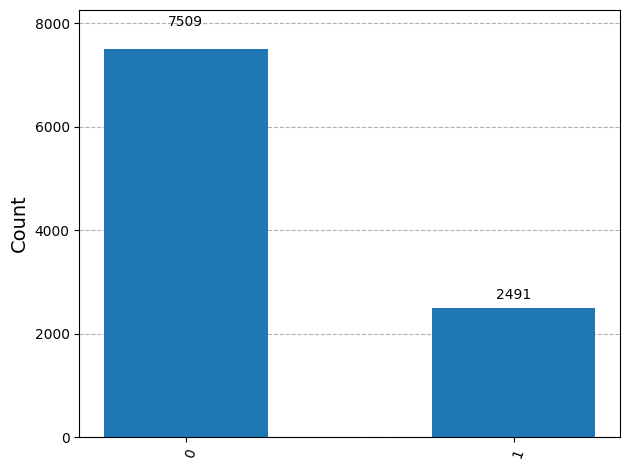

In [ ]:
qc_target = QuantumCircuit(1)

qc_target.ry(pi/3, 0)
qc_target.measure_all()

job = sampler.run([qc_target], shots=10000)
result = job.result()

counts_target = result[0].data.meas.get_counts()

print(counts_target)

plot_histogram(counts_target)

## 7.6 What Have We Learned About Rotation Gates?

Rotation gates provide continuous control over a qubit state.

| Gate            | Rotation Axis | Main Effect                                                                      |           |
| --------------- | ------------- | -------------------------------------------------------------------------------- | --------- |
| \(R_x(\theta)\) | x-axis        | Changes amplitudes and introduces relative phase                                 |           |
| \(R_y(\theta)\) | y-axis        | Changes amplitudes without introducing complex coefficients when starting from ( | 0\rangle) |
| \(R_z(\theta)\) | z-axis        | Primarily changes relative phase                                                 |           |

For a qubit initially in \(|0\rangle\),

$$
R_x(\theta)
$$

and

$$
R_y(\theta)
$$

can change the probabilities of measuring 0 and 1.

By contrast,

$$
R_z(\theta)
$$

does not directly change computational-basis measurement probabilities, but it changes phase information that can later influence interference.

### Important Insight

> **Rotation gates allow us to continuously control both the probability amplitudes and phase of a qubit.**

This is why parameterized rotation gates are central to many modern quantum algorithms.

### Connection to Fixed Gates

Several familiar gates can be understood as special cases of rotations, up to global phase.

For example,

$$
R_x(\pi)
$$

has the same observable effect as an X gate on computational-basis states.

Similarly, suitable rotations around the z-axis are closely related to phase gates.

In the next section, we will inspect the **statevector** directly and then use the **Bloch sphere** to visualize these rotations geometrically.


## 8. Obtaining and Interpreting the Statevector

Until now, we have mainly studied quantum circuits by **measuring** them.

Measurement gives us classical outcomes such as `0` and `1`. By repeating the experiment many times, we estimate their probabilities.

However, before measurement, a single qubit is described by a quantum state

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
$$

where \(\alpha\) and \(\beta\) are generally complex numbers called **probability amplitudes**.

The same state can be represented as a column vector:

$$
|\psi\rangle=
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}.
$$

This vector is called the **statevector**.

The amplitudes satisfy the normalization condition

$$
|\alpha|^2+|\beta|^2=1.
$$

The corresponding computational-basis measurement probabilities are

$$
P(0)=|\alpha|^2,
\qquad
P(1)=|\beta|^2.
$$

Therefore, the statevector provides more information than a measurement histogram: it contains both the **magnitudes** and **phases** of the quantum amplitudes.

In Qiskit, we can inspect the statevector directly using the `Statevector` class.

> **Important:** A statevector describes the quantum state before measurement. Therefore, when studying statevectors, we normally construct the circuit **without measurement operations**.


### 8.1 Statevector of the Initial State \(|0\rangle\)

Qiskit initializes a qubit in the state

$$
|0\rangle.
$$

Its statevector is

$$
|0\rangle=
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

Therefore,

$$
\alpha=1,\qquad\beta=0.
$$

The corresponding measurement probabilities are

$$
P(0)=|1|^2=1
$$

and

$$
P(1)=|0|^2=0.
$$

Let us verify this using Qiskit.


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)

state = Statevector.from_instruction(qc)

print(state)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


### Interpreting the Output

Qiskit displays the amplitudes as complex numbers:

`1.+0.j` represents

$$
1+0i
$$

and

`0.+0.j` represents

$$
0+0i.
$$

Therefore, the statevector

`[1.+0.j, 0.+0.j]`

means

$$
|\psi\rangle
=
1|0\rangle+0|1\rangle
=
|0\rangle.
$$

The **first element** is the amplitude of \(|0\rangle\), and the **second element** is the amplitude of \(|1\rangle\).


### 8.2 Statevector of \(|1\rangle\)

We previously learned that the X gate transforms

$$
X|0\rangle=|1\rangle.
$$

The statevector of \(|1\rangle\) is

$$
|1\rangle=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

### Predict

Before running the code, predict the two amplitudes that Qiskit should display after applying X to the initial state.


In [ ]:
qc_x = QuantumCircuit(1)

qc_x.x(0)

state_x = Statevector.from_instruction(qc_x)

print(state_x)

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


### 8.3 Statevector of the Superposition State

Now apply the Hadamard gate to \(|0\rangle\).

We know that

$$
H|0\rangle
=
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}.
$$

Therefore,

$$
\alpha=\frac{1}{\sqrt2},
\qquad
\beta=\frac{1}{\sqrt2}.
$$

Numerically,

$$
\frac{1}{\sqrt2}\approx0.7071.
$$

We therefore expect Qiskit to return approximately

$$
\begin{bmatrix}
0.7071\\
0.7071
\end{bmatrix}.
$$

### Predict

What probabilities should these two amplitudes produce when the qubit is measured?


In [ ]:
qc_h = QuantumCircuit(1)

qc_h.h(0)

state_h = Statevector.from_instruction(qc_h)

print(state_h)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


### 8.4 From Probability Amplitudes to Measurement Probabilities

The entries in a statevector are **amplitudes**, not probabilities.

For

$$
|\psi\rangle=
\alpha|0\rangle+\beta|1\rangle,
$$

the probabilities are obtained using

$$
P(0)=|\alpha|^2
$$

and

$$
P(1)=|\beta|^2.
$$

For the \(|+\rangle\) state,

$$
\alpha=\beta=\frac{1}{\sqrt2}.
$$

Therefore,

$$
P(0)=P(1)=
\left|\frac{1}{\sqrt2}\right|^2
=
\frac12.
$$

Let us calculate these probabilities directly from the statevector.


In [ ]:
alpha = state_h.data[0]
beta = state_h.data[1]

p0 = abs(alpha)**2
p1 = abs(beta)**2

print("Amplitude of |0> =", alpha)
print("Amplitude of |1> =", beta)

print("Probability of 0 =", p0)
print("Probability of 1 =", p1)

Amplitude of |0> = (0.7071067811865475+0j)
Amplitude of |1> = (0.7071067811865475+0j)
Probability of 0 = 0.4999999999999999
Probability of 1 = 0.4999999999999999


### 8.5 Obtaining Probabilities Directly

Qiskit's `Statevector` class can also calculate the computational-basis probabilities directly.

The method

`state.probabilities_dict()`

returns a dictionary containing each possible measurement outcome and its theoretical probability.

Unlike `StatevectorSampler`, this calculation does **not** perform repeated shots.

It calculates the probabilities directly from the statevector.


In [ ]:
probabilities = state_h.probabilities_dict()

print(probabilities)

{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


## 8.6 Seeing Quantum Phase in the Statevector

Earlier, we observed that the states

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

and

$$
|-\rangle=
\frac{|0\rangle-|1\rangle}{\sqrt2}
$$

produce identical probabilities when measured directly in the computational basis.

The statevector allows us to see the difference explicitly.

For \(|+\rangle\),

$$
\begin{bmatrix}
1/\sqrt2\\
1/\sqrt2
\end{bmatrix},
$$

while for \(|-\rangle\),

$$
\begin{bmatrix}
1/\sqrt2\\
-1/\sqrt2
\end{bmatrix}.
$$

The magnitudes of the amplitudes are identical, but the sign — and therefore the **relative phase** — is different.

Let us compare these states using Qiskit.


In [ ]:
# Prepare |+>
qc_plus = QuantumCircuit(1)
qc_plus.h(0)

state_plus = Statevector.from_instruction(qc_plus)

# Prepare |->
qc_minus = QuantumCircuit(1)
qc_minus.h(0)
qc_minus.z(0)

state_minus = Statevector.from_instruction(qc_minus)

print("|+> statevector:", state_plus.data)
print("|-> statevector:", state_minus.data)

|+> statevector: [0.70710678+0.j 0.70710678+0.j]
|-> statevector: [ 0.70710678+0.j -0.70710678+0.j]


In [ ]:
print("|+> probabilities:",
      state_plus.probabilities_dict())

print("|-> probabilities:",
      state_minus.probabilities_dict())

|+> probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
|-> probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


### What Does This Tell Us?

The experiment reveals an important distinction.

For \(|+\rangle\):

$$
\alpha=\frac{1}{\sqrt2},
\qquad
\beta=\frac{1}{\sqrt2}.
$$

For \(|-\rangle\):

$$
\alpha=\frac{1}{\sqrt2},
\qquad
\beta=-\frac{1}{\sqrt2}.
$$

Their measurement probabilities are identical:

$$
P(0)=P(1)=\frac12.
$$

However, their statevectors are different.

The statevector therefore contains **phase information that is lost when we look only at computational-basis measurement probabilities**.

This explains our earlier observation:

> **Two quantum states can have identical measurement probabilities in a particular basis while still being different quantum states.**


## 8.7 Statevector of a Rotated Qubit

In the previous section, we used \(R_y(\theta)\) to control measurement probabilities.

For a qubit initially in \(|0\rangle\),

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
+
\sin(\theta/2)|1\rangle.
$$

Let us revisit our earlier example:

$$
\theta=\frac{\pi}{3}.
$$

The theoretical state is

$$
|\psi\rangle
=
\cos(\pi/6)|0\rangle
+
\sin(\pi/6)|1\rangle.
$$

Since

$$
\cos(\pi/6)=\frac{\sqrt3}{2}\approx0.866
$$

and

$$
\sin(\pi/6)=\frac12,
$$

we expect the statevector to be approximately

$$
\begin{bmatrix}
0.866\\
0.5
\end{bmatrix}.
$$

This should produce

$$
P(0)=0.75,
\qquad
P(1)=0.25.
$$

Let us verify all three predictions using Qiskit.


In [ ]:
from numpy import pi

qc_ry = QuantumCircuit(1)

qc_ry.ry(pi/3, 0)

state_ry = Statevector.from_instruction(qc_ry)

print("Statevector:")
print(state_ry.data)

print("\nProbabilities:")
print(state_ry.probabilities_dict())

Statevector:
[0.8660254+0.j 0.5      +0.j]

Probabilities:
{np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.24999999999999994)}


## 8.8 Checking Statevector Normalization

Every valid quantum state must satisfy

$$
|\alpha|^2+|\beta|^2=1.
$$

This is called the **normalization condition**.

For our \(R_y(\pi/3)\) state,

$$
|\alpha|^2=0.75
$$

and

$$
|\beta|^2=0.25.
$$

Therefore,

$$
0.75+0.25=1.
$$

Let us verify the normalization directly from the Qiskit statevector.


In [ ]:
alpha = state_ry.data[0]
beta = state_ry.data[1]

normalization = abs(alpha)**2 + abs(beta)**2

print("alpha =", alpha)
print("beta  =", beta)
print("Normalization =", normalization)

alpha = (0.8660254037844387+0j)
beta  = (0.49999999999999994+0j)
Normalization = 1.0


## 8.9 Exercise — Predict the Statevector

For each of the following circuits, **predict the statevector before executing the code**.

### Circuit A

$$
|0\rangle \xrightarrow{X}
$$

### Circuit B

$$
|0\rangle \xrightarrow{H}
$$

### Circuit C

$$
|0\rangle \xrightarrow{H}\xrightarrow{Z}
$$

### Circuit D

$$
|0\rangle \xrightarrow{R_y(\pi/2)}
$$

For each circuit:

1. Write the expected state in Dirac notation.
2. Predict \(\alpha\) and \(\beta\).
3. Predict \(P(0)\) and \(P(1)\).
4. Construct the circuit in Qiskit.
5. Obtain its statevector.
6. Use `probabilities_dict()` to verify your probability calculation.
7. Explain any difference between your prediction and the Qiskit result.

### Challenge

Construct two different single-qubit states that have:

$$
P(0)=P(1)=0.5
$$

but have different statevectors.

Explain why computational-basis measurement alone cannot distinguish them.


## 8.10 Statevector — Key Concepts

A single-qubit state can be written as

$$
|\psi\rangle
=
\alpha|0\rangle+\beta|1\rangle
$$

or equivalently as the statevector

$$
|\psi\rangle=
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}.
$$

The statevector contains the **complex probability amplitudes** of the quantum state.

Measurement probabilities are obtained from

$$
P(0)=|\alpha|^2,
\qquad
P(1)=|\beta|^2.
$$

A valid quantum state must satisfy

$$
|\alpha|^2+|\beta|^2=1.
$$

### Statevector vs Measurement Counts

| Statevector                                       | Measurement Counts                      |
| ------------------------------------------------- | --------------------------------------- |
| Describes the quantum state                       | Describes observed measurement outcomes |
| Contains complex amplitudes                       | Contains classical counts               |
| Contains relative-phase information               | Phase is not directly visible           |
| Gives exact ideal-state information in simulation | Depends on number of shots              |
| Used before measurement                           | Obtained after measurement              |

### Key Takeaway

> **The statevector tells us what quantum state we have; measurement tells us what classical outcome we observe.**

Understanding this distinction is essential because quantum algorithms manipulate **probability amplitudes and their phases**, not merely measurement probabilities.

In the next section, we will give the statevector a geometric interpretation using the **Bloch sphere**.


## 9. Visualizing a Single Qubit Using the Bloch Sphere

A single-qubit state

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle
$$

can also be represented geometrically as a point on the surface of a sphere called the **Bloch sphere**.

Ignoring an overall global phase, any pure single-qubit state can be written as

$$
|\psi\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}
\sin\left(\frac{\theta}{2}\right)|1\rangle.
$$

The two angles have geometric meaning:

* \(\theta\) determines the position between the north and south poles.
* \(\phi\) determines the rotation around the equator.

Important reference states are:

$$
|0\rangle \rightarrow +Z
$$

$$
|1\rangle \rightarrow -Z
$$

$$
|+\rangle \rightarrow +X
$$

$$
|-\rangle \rightarrow -X
$$

$$
|+i\rangle \rightarrow +Y
$$

$$
|-i\rangle \rightarrow -Y.
$$

The Bloch sphere helps us see information that may not be obvious from a computational-basis measurement histogram, particularly **relative phase**.

In Qiskit, we can visualize a statevector using:

`plot_bloch_multivector(state)`

In this section, we will connect:

> **Quantum Circuit → Statevector → Bloch Sphere**


### 9.1 The State \(|0\rangle\)

A newly initialized Qiskit qubit is in the state

$$
|0\rangle=
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

On the Bloch sphere, \(|0\rangle\) lies at the **north pole**, along the positive z-axis.

### Predict

Before displaying the Bloch sphere, where do you expect the state vector to point?

* +X
* −X
* +Y
* −Y
* +Z
* −Z


Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


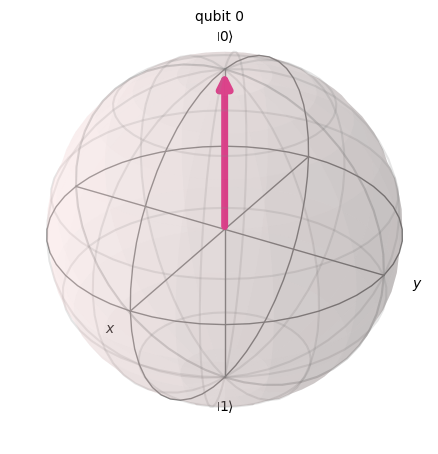

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc_0 = QuantumCircuit(1)

state_0 = Statevector.from_instruction(qc_0)

print(state_0)
plot_bloch_multivector(state_0)

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


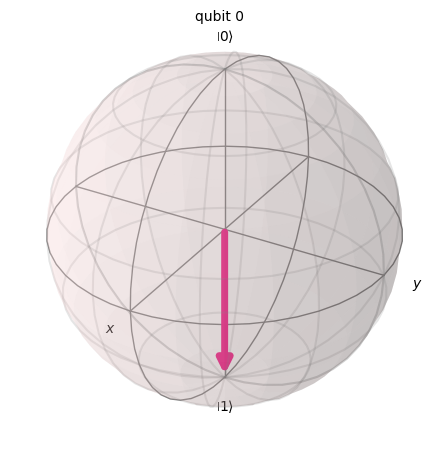

In [ ]:
qc_1 = QuantumCircuit(1)

qc_1.x(0)

state_1 = Statevector.from_instruction(qc_1)

print(state_1)
plot_bloch_multivector(state_1)

### 9.3 The \(|+\rangle\) State

Applying a Hadamard gate to \(|0\rangle\) produces

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}.
$$

Its statevector is

$$
\frac{1}{\sqrt2}
\begin{bmatrix}
1\\
1
\end{bmatrix}.
$$

The probabilities of measuring `0` and `1` are both 50%.

Geometrically, however, the qubit is not located halfway between the north and south poles inside the sphere. A pure state remains on the **surface** of the Bloch sphere.

The \(|+\rangle\) state points along the **positive x-axis**.

### Predict

Where will the Bloch vector point after applying H to \(|0\rangle\)?


Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


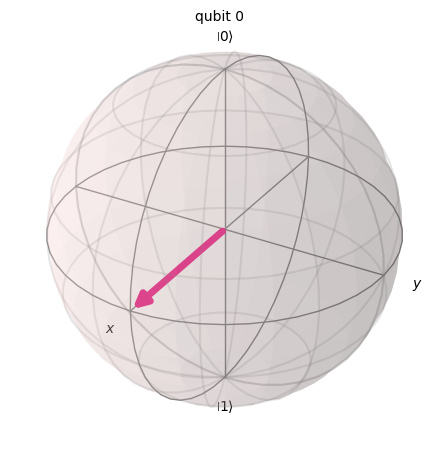

In [ ]:
qc_plus = QuantumCircuit(1)

qc_plus.h(0)

state_plus = Statevector.from_instruction(qc_plus)

print(state_plus)
plot_bloch_multivector(state_plus)

### 9.4 Seeing Relative Phase Geometrically

Now consider

$$
|-\rangle=
\frac{|0\rangle-|1\rangle}{\sqrt2}.
$$

Both \(|+\rangle\) and \(|-\rangle\) have identical computational-basis probabilities:

$$
P(0)=P(1)=\frac12.
$$

However, their relative phases differ.

On the Bloch sphere,

$$
|+\rangle \rightarrow +X
$$

whereas

$$
|-\rangle \rightarrow -X.
$$

This gives us a geometric demonstration that two states with identical computational-basis measurement probabilities can still be different quantum states.

We can prepare \(|-\rangle\) by applying

$$
H \rightarrow Z
$$

to \(|0\rangle\).


Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


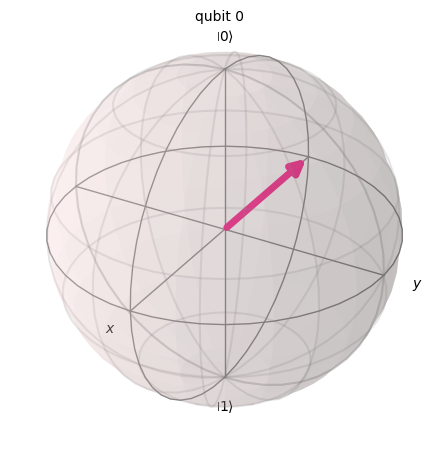

In [ ]:
qc_minus = QuantumCircuit(1)

qc_minus.h(0)
qc_minus.z(0)

state_minus = Statevector.from_instruction(qc_minus)

print(state_minus)
plot_bloch_multivector(state_minus)

## 9.5 The \(+Y\) State

Another important single-qubit state is

$$
|+i\rangle
=
\frac{|0\rangle+i|1\rangle}{\sqrt2}.
$$

Its computational-basis probabilities are again

$$
P(0)=P(1)=\frac12.
$$

However, its relative phase is different from both \(|+\rangle\) and \(|-\rangle\).

On the Bloch sphere,

$$
|+i\rangle
$$

points along the **positive y-axis**.

We can prepare this state by applying a Hadamard gate followed by an S phase gate:

$$
|0\rangle
\xrightarrow{H}
|+\rangle
\xrightarrow{S}
|+i\rangle.
$$

### Predict

All three states

$$
|+\rangle,\quad |-\rangle,\quad |+i\rangle
$$

give 50%–50% probabilities in the computational basis.

Will they occupy the same point on the Bloch sphere?


In [ ]:
qc_yplus = QuantumCircuit(1)

qc_yplus.h(0)
qc_yplus.s(0)

state_yplus = Statevector.from_instruction(qc_yplus)

print(state_yplus)
plot_bloch_multivector(state_yplus)

## 9.6 Six Important States on the Bloch Sphere

The six directions along the x, y, and z axes correspond to six important single-qubit states.

| Bloch Direction | Quantum State | State      |             |            |                   |
| --------------- | ------------- | ---------- | ----------- | ---------- | ----------------- |
| +Z              | (             | 0\rangle)  | \([1,0]^T\) |            |                   |
| −Z              | (             | 1\rangle)  | \([0,1]^T\) |            |                   |
| +X              | (             | +\rangle)  | ((          | 0\rangle+  | 1\rangle)/\sqrt2) |
| −X              | (             | -\rangle)  | ((          | 0\rangle-  | 1\rangle)/\sqrt2) |
| +Y              | (             | +i\rangle) | ((          | 0\rangle+i | 1\rangle)/\sqrt2) |
| −Y              | (             | -i\rangle) | ((          | 0\rangle-i | 1\rangle)/\sqrt2) |

These states provide useful landmarks for understanding single-qubit operations.

Notice that the four equatorial states all have

$$
P(0)=P(1)=\frac12
$$

when measured in the computational basis.

They are distinguished by their **relative phases**, represented geometrically by different directions around the equator.


## 9.7 Visualizing a Rotation Around the Y-Axis

Earlier, we learned that

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
+
\sin(\theta/2)|1\rangle.
$$

On the Bloch sphere, \(R_y(\theta)\) rotates the Bloch vector around the **y-axis** by angle \(\theta\).

Starting from \(|0\rangle\):

* \(R_y(0)\) leaves the state at +Z.
* \(R_y(\pi/2)\) moves the state to +X.
* \(R_y(\pi)\) moves the state to −Z.

Let us visualize these rotations.


In [ ]:
from numpy import pi

qc_ry_45 = QuantumCircuit(1)
qc_ry_45.ry(pi/4, 0)

state_ry_45 = Statevector.from_instruction(qc_ry_45)

plot_bloch_multivector(state_ry_45)

In [ ]:
qc_ry_90 = QuantumCircuit(1)
qc_ry_90.ry(pi/2, 0)

state_ry_90 = Statevector.from_instruction(qc_ry_90)

plot_bloch_multivector(state_ry_90)

In [ ]:
qc_ry_180 = QuantumCircuit(1)
qc_ry_180.ry(pi, 0)

state_ry_180 = Statevector.from_instruction(qc_ry_180)

plot_bloch_multivector(state_ry_180)

### Observation

As the angle increases, the Bloch vector moves continuously from the north pole toward the south pole.

$$
|0\rangle
\xrightarrow{R_y(\pi/2)}
|+\rangle
\xrightarrow{R_y(\pi/2)}
|1\rangle.
$$

This gives us a geometric interpretation of a parameterized quantum gate:

> **Changing the rotation angle continuously changes the orientation of the quantum state.**

The corresponding computational-basis probabilities also change because the vector's position relative to the z-axis changes.

```



## 9.8 Visualizing Phase with \(R_z\)

An \(R_z\) rotation changes the **relative phase** of a superposition.

If we apply \(R_z\) directly to \(|0\rangle\), the Bloch vector remains at the north pole. Therefore, its effect is not visually interesting in that case.

Instead, first prepare

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2},
$$

which points along +X.

Then apply \(R_z(\theta)\).

On the Bloch sphere, the vector rotates around the z-axis while remaining on the equator.

For example:

$$
R_z(\pi/2)
$$

moves the vector from +X toward +Y.

Importantly, throughout this rotation,

$$
P(0)=P(1)=\frac12.
$$

The computational-basis probabilities remain unchanged even though the quantum state moves around the Bloch sphere.

This provides a geometric interpretation of **quantum phase**.


In [ ]:
qc_rz_start = QuantumCircuit(1)

qc_rz_start.h(0)

state_rz_start = Statevector.from_instruction(qc_rz_start)

plot_bloch_multivector(state_rz_start)

{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


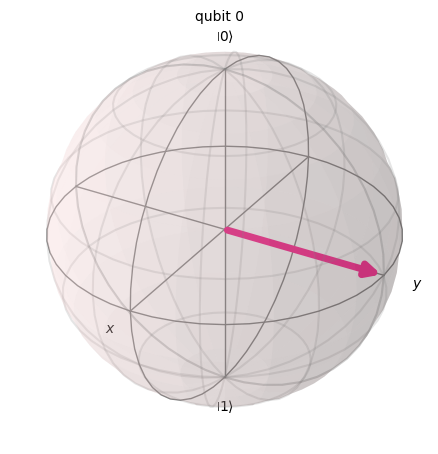

In [ ]:
qc_rz_90 = QuantumCircuit(1)

qc_rz_90.h(0)
qc_rz_90.rz(pi/2, 0)

state_rz_90 = Statevector.from_instruction(qc_rz_90)

print(state_rz_90.probabilities_dict())
plot_bloch_multivector(state_rz_90)

## 9.9 Bloch Sphere and Measurement Probability

The position of a state on the Bloch sphere provides a geometric interpretation of measurement probabilities.

For

$$
|\psi\rangle
=
\cos(\theta/2)|0\rangle
+
e^{i\phi}\sin(\theta/2)|1\rangle,
$$

the computational-basis probabilities are

$$
P(0)=\cos^2(\theta/2)
$$

and

$$
P(1)=\sin^2(\theta/2).
$$

Notice that these probabilities depend on \(\theta\), but not directly on \(\phi\).

Therefore:

* moving from north to south changes computational-basis probabilities;
* moving around the equator changes phase while keeping computational-basis probabilities unchanged.

This gives a useful geometric interpretation:

> **Latitude-like movement changes measurement probabilities, while rotation around the z-axis changes relative phase.**


## 9.10 Exercise — Predict Before You Plot

For each circuit below, first predict the direction of the Bloch vector.

### A

```text
X
```

### B

```text
H
```

### C

```text
H → Z
```

### D

```text
H → S
```

### E

```text
R_y(π/2)
```

### F

```text
H → R_z(π/2)
```

For each circuit:

1. Predict the resulting quantum state.
2. Write its statevector if possible.
3. Predict its computational-basis probabilities.
4. Predict its approximate Bloch-sphere direction.
5. Construct the circuit.
6. Obtain the statevector.
7. Plot the Bloch sphere.
8. Compare the visualization with your prediction.

### Challenge

Construct a circuit that prepares a state whose Bloch vector lies:

* halfway between +Z and +X;
* on the −Y axis;
* on the equator but not on the X or Y axes.

Use rotation gates to create the states and verify them with the Bloch sphere.


## 9.11 What Have We Learned from the Bloch Sphere?

The Bloch sphere gives us a geometric representation of a pure single-qubit state.

The poles represent the computational-basis states:

$$
|0\rangle \rightarrow +Z
$$

and

$$
|1\rangle \rightarrow -Z.
$$

Superposition states appear at other positions on the sphere.

For example,

$$
|+\rangle \rightarrow +X,
$$

$$
|-\rangle \rightarrow -X,
$$

$$
|+i\rangle \rightarrow +Y.
$$

### Three Complementary Views of a Qubit

We can now describe a single qubit in three different but related ways:

| Representation | Example             | What it tells us         |                   |                          |
| -------------- | ------------------- | ------------------------ | ----------------- | ------------------------ |
| Dirac notation | ((                  | 0\rangle+                | 1\rangle)/\sqrt2) | Mathematical description |
| Statevector    | \([0.707,0.707]^T\) | Complex amplitudes       |                   |                          |
| Bloch sphere   | Vector along +X     | Geometric interpretation |                   |                          |

Measurement gives us a fourth view:

$$
P(0),\quad P(1).
$$

But measurement probabilities alone do not contain all the information in the quantum state.

### Central Insight

> **The statevector describes the amplitudes mathematically; the Bloch sphere represents the same single-qubit state geometrically.**

The Bloch sphere also makes the distinction between **probability and phase** intuitive:

* motion toward or away from the poles changes computational-basis probabilities;
* motion around the z-axis changes relative phase;
* quantum gates can therefore be understood geometrically as rotations of the Bloch vector.

This completes our basic exploration of the single qubit.
